# Point Charge on a Spring (Euler Method)

We model a point charge attached to an ideal spring in 1D with spring potential

$V(x)=\frac{1}{2}kx^2$.

From the potential, the spring force is

$F(x)=-\frac{dV}{dx}=-kx$.

Using Newton's 2nd law for mass $m$:

$m\ddot{x}=-kx \Rightarrow \ddot{x}=-(k/m)x$.

We solve this numerically with the **explicit Euler method** (simple and direct):

- $a_n = -(k/m)x_n$
- $v_{n+1} = v_n + a_n\Delta t$
- $x_{n+1} = x_n + v_n\Delta t$

In [177]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Physical parameters -----
m = 1.0      # mass (kg)
k = 4.0      # spring constant (N/m)
q = 1.0      # point charge (C), included for context

# ----- Initial conditions -----
x0 = 0.2    # initial position (m)
v0 = 0.00    # initial velocity (m/s)

# ----- Time settings -----
dt = 0.0001   # time step (s)
t_max = 10.0 # total simulation time (s)
N = int(t_max / dt) + 1
t = np.linspace(0, t_max, N)

In [178]:
# Allocate arrays
x = np.zeros(N)
v = np.zeros(N)
a = np.zeros(N)

# Set initial values
x[0] = x0
v[0] = v0
a[0] = -(k/m) * x[0]

# Euler integration loop
for n in range(N - 1):
    a[n] = -(k/m) * x[n]
    v[n + 1] = v[n] + a[n] * dt
    x[n + 1] = x[n] + v[n] * dt

# Final acceleration
a[-1] = -(k/m) * x[-1]

In [179]:
# Energies
K = 0.5 * m * v**2          # kinetic
U = 0.5 * k * x**2          # spring potential
E = K + U                   # total energy

# Useful analytical reference for SHO (optional check)
omega = np.sqrt(k/m)
x_exact = x0 * np.cos(omega * t) + (v0/omega) * np.sin(omega * t)

period = 2*np.pi/omega
print(f"Natural frequency omega = {omega:.4f} rad/s")
print(f"Period T = {period:.4f} s")
print(f"Initial total energy = {E[0]:.6f} J")
print(f"Final total energy   = {E[-1]:.6f} J")

Natural frequency omega = 2.0000 rad/s
Period T = 3.1416 s
Initial total energy = 0.080000 J
Final total energy   = 0.080321 J


Saved figure to point_charge_spring_euler_output.png
Final percent difference (E0 vs Ef): 0.400801%


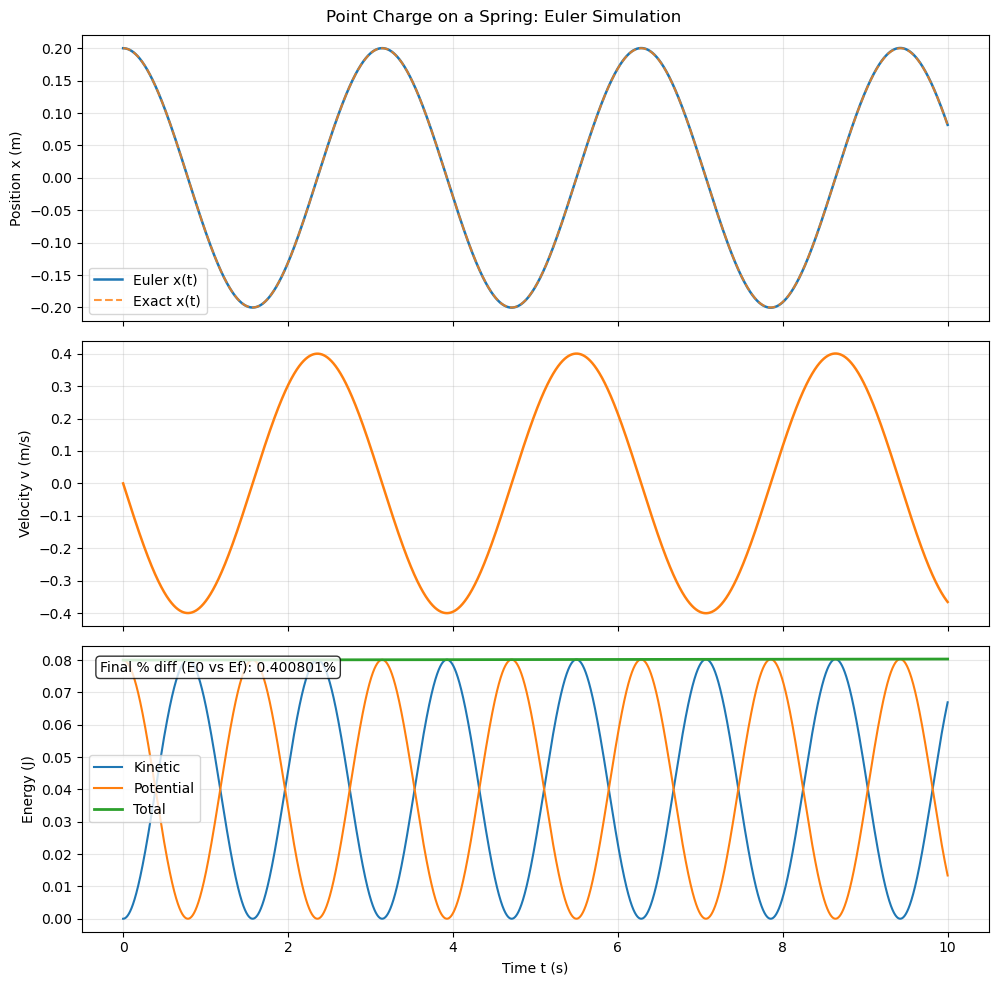

In [180]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t, x, label='Euler x(t)', linewidth=1.8)
axs[0].plot(t, x_exact, '--', label='Exact x(t)', alpha=0.8)
axs[0].set_ylabel('Position x (m)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(t, v, color='tab:orange', linewidth=1.8)
axs[1].set_ylabel('Velocity v (m/s)')
axs[1].grid(True, alpha=0.3)

axs[2].plot(t, K, label='Kinetic')
axs[2].plot(t, U, label='Potential')
axs[2].plot(t, E, label='Total', linewidth=2)
axs[2].set_xlabel('Time t (s)')
axs[2].set_ylabel('Energy (J)')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

# Final percent difference in total energy
percent_diff_E = abs((E[-1] - E[0]) / E[0]) * 100
axs[2].text(
    0.02, 0.95,
    f'Final % diff (E0 vs Ef): {percent_diff_E:.6f}%',
    transform=axs[2].transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
 )

plt.suptitle('Point Charge on a Spring: Euler Simulation')
plt.tight_layout()

output_image_path = 'point_charge_spring_euler_output.png'
plt.savefig(output_image_path, dpi=160, bbox_inches='tight')
print(f'Saved figure to {output_image_path}')
print(f'Final percent difference (E0 vs Ef): {percent_diff_E:.6f}%')

plt.show()

#### JC1: This shouldnt have an increase in total energy because its just a simple harmonic oscillator converting from potential to kinetic. What happens if i change my step size?

### dt = 0.01
<img src="../ouptut_h_0_01.png" alt="h = 0.01" width="50%" />

### dt = 0.0001
<img src="../output_h_0_0001.png" alt="h = 0.0001" width="50%" />

#### now we see that Energy looks conserved but no matter what if i change the step size there is a percent difference of 0.04% which shouldn't be anyhting but 0. But realistically anything else would increase trunctuation error or round off error. In addition to that more values of $ 10^{-n} $ bloats the time significantly, and to save time im gonna use dt 0.0001 which has a percent difference of 0.4%

#### other than that it behaves like a simple harmonic oscillator based off the graphs, whenever there is a maximum or minimum value the velocity is at 0

## Wind Forcing (Random Gusts)

In [181]:
# Wind forcing: random gusts that appear and ramp up/down
# Gust sign can be positive or negative:
#   positive gust -> damping (slows particle)
#   negative gust -> anti-damping (speeds particle)

np.random.seed()  # random each run

# Wind parameters (ranges)
wind_strength_min = 0.1     # min |gust coefficient| (N·s/m)
wind_strength_max = 0.9     # max |gust coefficient| (N·s/m)
gust_duration_min = 0.2     # min duration (s)
gust_duration_max = 0.5     # max duration (s)

# Generate wind signal
wind_force = np.zeros(N)
gust_active = False
gust_end_time = 0
gust_start_time = 0
current_gust_strength = 0.0   # signed (+/-) gust coefficient
current_gust_duration = 0.0

for n in range(N):
    t_n = t[n]
    
    # Decide if a new gust should start
    if not gust_active and t_n >= gust_end_time:
        if np.random.rand() < 0.15:  # 15% chance per timestep
            gust_active = True
            gust_start_time = t_n
            
            # Randomize THIS gust duration and signed strength
            gust_mag = np.random.uniform(wind_strength_min, wind_strength_max)
            gust_sign = np.random.choice([-1.0, 1.0])
            current_gust_strength = gust_sign * gust_mag
            current_gust_duration = np.random.uniform(gust_duration_min, gust_duration_max)
            
            gust_end_time = t_n + current_gust_duration
    
    # If gust is active, ramp wind coefficient
    if gust_active and t_n <= gust_end_time:
        elapsed = t_n - gust_start_time
        if elapsed < current_gust_duration / 2:
            ramp = elapsed / (current_gust_duration / 2)  # ramp up
        else:
            ramp = 1 - (elapsed - current_gust_duration / 2) / (current_gust_duration / 2)  # ramp down
        wind_force[n] = current_gust_strength * ramp
    else:
        gust_active = False
        wind_force[n] = 0.0

print(f"Active gust timesteps: {np.sum(wind_force != 0)}")
print(f"Positive gust timesteps (slow-down): {np.sum(wind_force > 0)}")
print(f"Negative gust timesteps (speed-up): {np.sum(wind_force < 0)}")

Active gust timesteps: 99755
Positive gust timesteps (slow-down): 25614
Negative gust timesteps (speed-up): 74141


In [182]:
# Re-run simulation with wind forcing
x_wind = np.zeros(N)
v_wind = np.zeros(N)
a_wind = np.zeros(N)

# Set initial values
x_wind[0] = x0
v_wind[0] = v0

# Euler integration loop WITH wind
for n in range(N - 1):
    # Spring force
    F_spring = -(k/m) * x_wind[n]
    
    # Wind damping force (opposes motion)
    F_wind = -wind_force[n] * v_wind[n]
    
    # Total acceleration
    a_wind[n] = F_spring + F_wind
    
    # Euler update
    v_wind[n + 1] = v_wind[n] + a_wind[n] * dt
    x_wind[n + 1] = x_wind[n] + v_wind[n] * dt

# Final acceleration
a_wind[-1] = -(k/m) * x_wind[-1] - wind_force[-1] * v_wind[-1]

# Energies with wind
K_wind = 0.5 * m * v_wind**2
U_wind = 0.5 * k * x_wind**2
E_wind = K_wind + U_wind

print(f"\nWith wind forcing:")
print(f"Initial total energy = {E_wind[0]:.6f} J")
print(f"Final total energy   = {E_wind[-1]:.6f} J")
print(f"Energy dissipated by wind = {E_wind[0] - E_wind[-1]:.6f} J")


With wind forcing:
Initial total energy = 0.080000 J
Final total energy   = 0.357692 J
Energy dissipated by wind = -0.277692 J


No-wind final percent difference (E0 vs Ef): 0.400801%
With-wind final percent difference (E0 vs Ef): 347.114621%


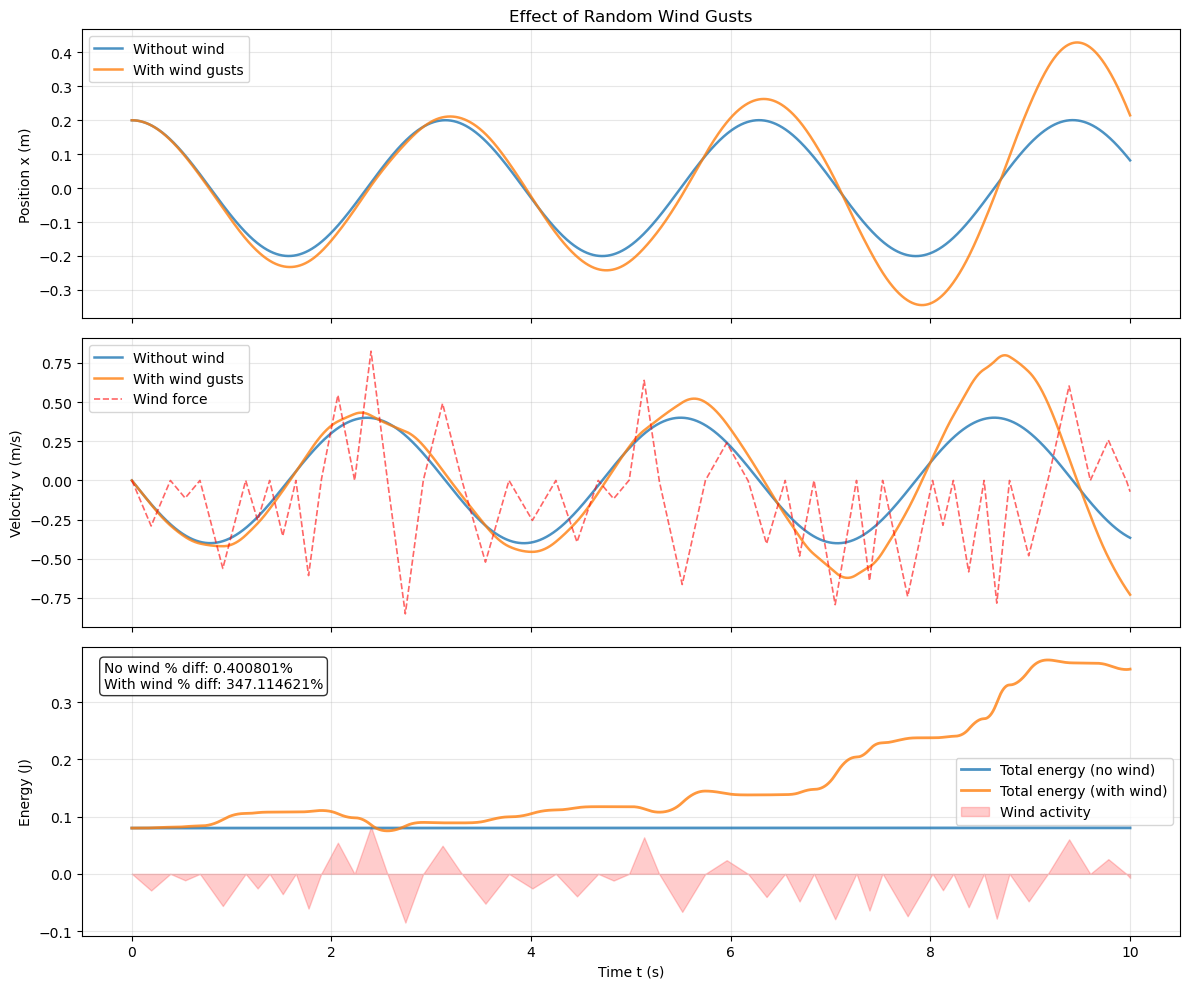

In [183]:
# Compare: without wind vs with wind
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Position comparison
axs[0].plot(t, x, label='Without wind', linewidth=1.8, alpha=0.8)
axs[0].plot(t, x_wind, label='With wind gusts', linewidth=1.8, alpha=0.8)
axs[0].set_ylabel('Position x (m)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)
axs[0].set_title('Effect of Random Wind Gusts')

# Velocity comparison
axs[1].plot(t, v, label='Without wind', linewidth=1.8, alpha=0.8)
axs[1].plot(t, v_wind, label='With wind gusts', linewidth=1.8, alpha=0.8)
axs[1].plot(t, wind_force, '--', color='red', label='Wind force', linewidth=1.2, alpha=0.6)
axs[1].set_ylabel('Velocity v (m/s)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Energy comparison
axs[2].plot(t, E, label='Total energy (no wind)', linewidth=2, alpha=0.8)
axs[2].plot(t, E_wind, label='Total energy (with wind)', linewidth=2, alpha=0.8)
axs[2].fill_between(t, 0, wind_force * 0.1, alpha=0.2, color='red', label='Wind activity')
axs[2].set_xlabel('Time t (s)')
axs[2].set_ylabel('Energy (J)')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

# Final percent differences in total energy
percent_diff_no_wind = abs((E[-1] - E[0]) / E[0]) * 100
percent_diff_with_wind = abs((E_wind[-1] - E_wind[0]) / E_wind[0]) * 100

axs[2].text(
    0.02, 0.95,
    f'No wind % diff: {percent_diff_no_wind:.6f}%\nWith wind % diff: {percent_diff_with_wind:.6f}%',
    transform=axs[2].transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
 )

print(f'No-wind final percent difference (E0 vs Ef): {percent_diff_no_wind:.6f}%')
print(f'With-wind final percent difference (E0 vs Ef): {percent_diff_with_wind:.6f}%')

plt.tight_layout()
plt.show()

#### JC2: This section I implemented a wind force thats governed by a random length, strength, and direction. The random length affects how long each magnitude of wind gusts the particle experiences. Random strength tells how much force it will add in the given direction. Random direction is only positive or negative, if positive then it slows down the particle, and negative speeds the oscillations up. how i can tell its working appropriately is go through the same checks, does energy change and should it be conserved? Does it behave like a spring where velocity and positions are in opposite phase. And something different to check is if it is random

### Test 1
<img src="../jc2_test_1_updated.png" alt="Test 1" width="70%" />

### Test 2
<img src="../jc2_test_2_updated.png" alt="Test 2" width="70%" />

### Test 3
<img src="../jc2_test_3_updated.png" alt="Test 3" width="70%" />

## Anharmonic Oscillations (Power-Law Potentials)

For anharmonic oscillators, we modify the potential to:

$$V(x) = \frac{1}{n} k x^n$$

where $n > 2$ (for $n=2$, we recover the harmonic oscillator). The force becomes:

$$F(x) = -\frac{dV}{dx} = -k x^{n-1}$$

This creates a **nonlinear** restoring force. Unlike the harmonic case, there is no simple analytical solution for $n > 2$.

We will test different powers $n \in \{3, 4, 5, 6\}$ and different time steps $dt \in \{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}, 10^{-5}\}$ to study the numerical stability and accuracy of the Euler method for increasingly nonlinear systems.

In [219]:
# Parameters for anharmonic oscillator study
n_values = [4, 6, 8, 10]  # Different powers for V(x) = (1/n)*k*x^n
dt_values = [0.1, 0.01, 0.001, 0.0001, 0.00001]  # Different time steps

# Storage for results: {n: {dt: {'x': array, 'v': array, 't': array, 'E': array, 'percent_diff': float}}}
results = {}

# Use some of the same physical parameters
# m = 1.0 kg, k = 4.0 N/m, v0 = 0.0 m/s (already defined above)
x0 = 1.0
k = 10.0

t_max_anh = 20.0  # Shorter simulation for anharmonic cases

In [220]:
# Run simulations for all combinations of n and dt
import time
print("Running anharmonic oscillator simulations...")
print(f"Testing {len(n_values)} power values × {len(dt_values)} time steps = {len(n_values)*len(dt_values)} total simulations\n")

start_time = time.time()

for n in n_values:
    results[n] = {}
    
    for dt_anh in dt_values:
        # Number of time steps
        N_anh = int(t_max_anh / dt_anh)
        t_anh = np.linspace(0, t_max_anh, N_anh)
        
        # Initialize arrays
        x_anh = np.zeros(N_anh)
        v_anh = np.zeros(N_anh)
        a_anh = np.zeros(N_anh)
        
        # Initial conditions
        x_anh[0] = x0
        v_anh[0] = v0
        
        # Euler method for anharmonic oscillator: F = -k*x^(n-1)
        for i in range(N_anh - 1):
            # Acceleration: a = F/m = -k*x^(n-1)/m
            a_anh[i] = -(k / m) * (x_anh[i] ** (n - 1))
            
            # Update velocity and position
            v_anh[i + 1] = v_anh[i] + a_anh[i] * dt_anh
            x_anh[i + 1] = x_anh[i] + v_anh[i] * dt_anh
        
        # Calculate final acceleration
        a_anh[-1] = -(k / m) * (x_anh[-1] ** (n - 1))
        
        # Calculate energy: E = (1/2)mv^2 + (1/n)kx^n
        K_anh = 0.5 * m * v_anh**2
        U_anh = (1/n) * k * (x_anh ** n)
        E_anh = K_anh + U_anh
        
        # Calculate percent difference in energy
        percent_diff_anh = abs((E_anh[-1] - E_anh[0]) / E_anh[0]) * 100
        
        # Store results
        results[n][dt_anh] = {
            'x': x_anh,
            'v': v_anh,
            't': t_anh,
            'E': E_anh,
            'percent_diff': percent_diff_anh,
            'E_initial': E_anh[0],
            'E_final': E_anh[-1]
        }
        
        print(f"n={n}, dt={dt_anh:0.5f}: Energy drift = {percent_diff_anh:8.4f}%")
    
    print()  # Blank line between different n values

end_time = time.time()
print(f"Total computation time: {end_time - start_time:.2f} seconds")

Running anharmonic oscillator simulations...
Testing 4 power values × 5 time steps = 20 total simulations

n=4, dt=0.10000: Energy drift =      nan%
n=4, dt=0.01000: Energy drift =      nan%
n=4, dt=0.00100: Energy drift =  26.0661%
n=4, dt=0.00010: Energy drift =   2.2410%


/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_32136/3449036933.py:28: RuntimeWarning: overflow encountered in scalar power
  a_anh[i] = -(k / m) * (x_anh[i] ** (n - 1))
/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_32136/3449036933.py:31: RuntimeWarning: invalid value encountered in scalar add
  v_anh[i + 1] = v_anh[i] + a_anh[i] * dt_anh
/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_32136/3449036933.py:38: RuntimeWarning: overflow encountered in square
  K_anh = 0.5 * m * v_anh**2
/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_32136/3449036933.py:39: RuntimeWarning: overflow encountered in power
  U_anh = (1/n) * k * (x_anh ** n)


n=4, dt=0.00001: Energy drift =   0.2203%

n=6, dt=0.10000: Energy drift =      nan%
n=6, dt=0.01000: Energy drift =      nan%
n=6, dt=0.00100: Energy drift =  28.1167%
n=6, dt=0.00010: Energy drift =   2.3744%
n=6, dt=0.00001: Energy drift =   0.2321%

n=8, dt=0.10000: Energy drift =      nan%
n=8, dt=0.01000: Energy drift =      nan%
n=8, dt=0.00100: Energy drift =  30.5171%
n=8, dt=0.00010: Energy drift =   2.3999%
n=8, dt=0.00001: Energy drift =   0.2365%

n=10, dt=0.10000: Energy drift =      nan%
n=10, dt=0.01000: Energy drift =      nan%
n=10, dt=0.00100: Energy drift =  31.7946%
n=10, dt=0.00010: Energy drift =   2.4678%
n=10, dt=0.00001: Energy drift =   0.2430%

Total computation time: 3.99 seconds


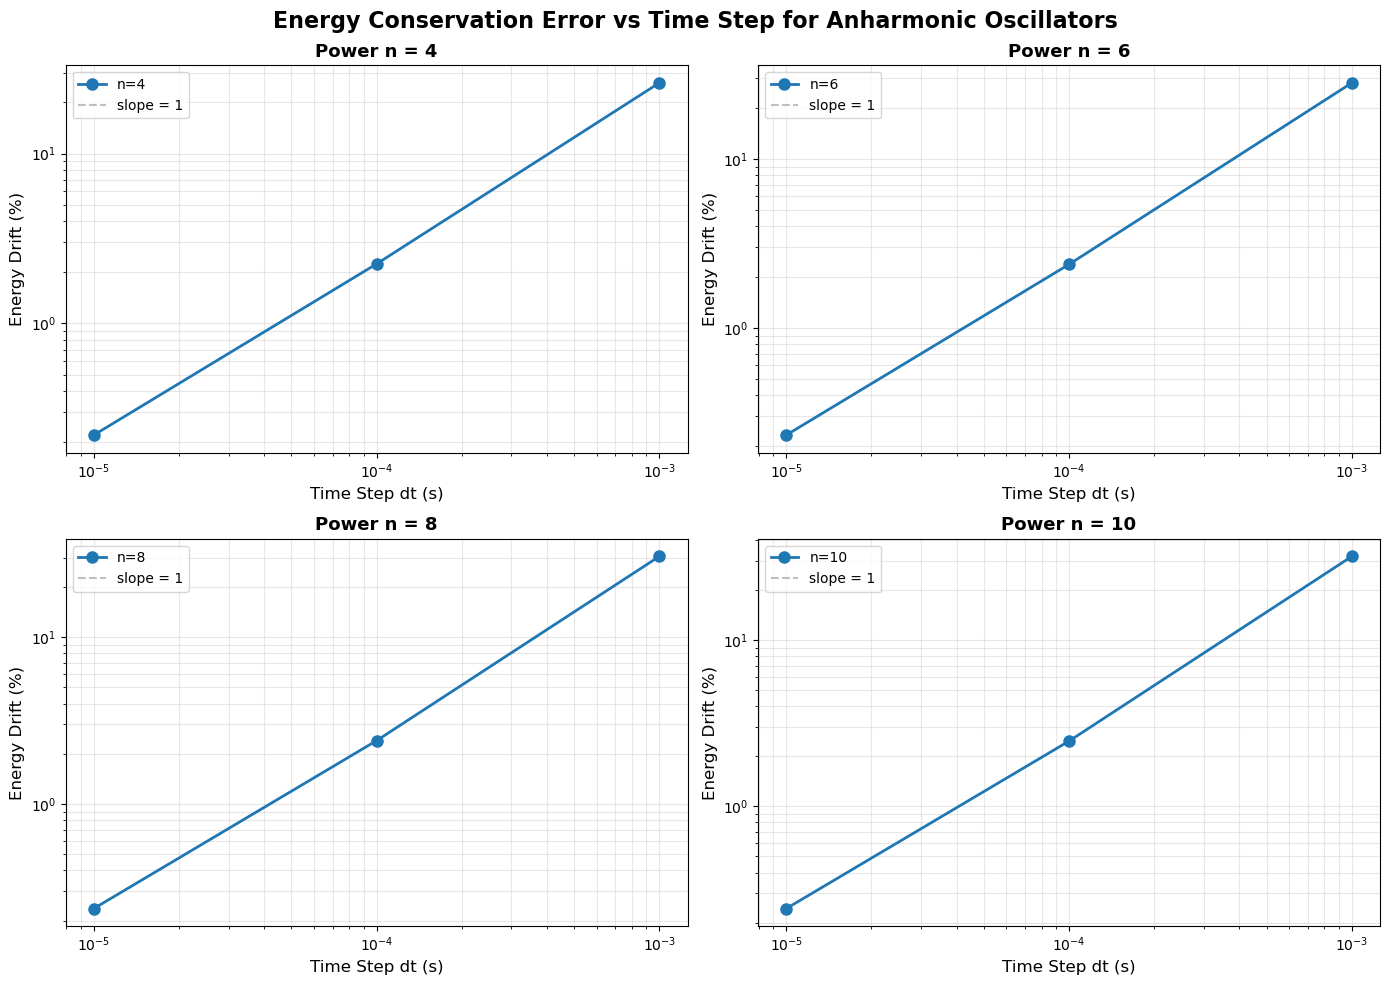

In [221]:
# Plot energy drift vs time step for each power n
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Energy Conservation Error vs Time Step for Anharmonic Oscillators', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, n in enumerate(n_values):
    ax = axes[idx]
    
    # Extract percent differences for this n
    percent_diffs = [results[n][dt_anh]['percent_diff'] for dt_anh in dt_values]
    
    # Plot on log-log scale
    ax.loglog(dt_values, percent_diffs, 'o-', linewidth=2, markersize=8, label=f'n={n}')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('Time Step dt (s)', fontsize=12)
    ax.set_ylabel('Energy Drift (%)', fontsize=12)
    ax.set_title(f'Power n = {n}', fontsize=13, fontweight='bold')
    ax.legend()
    
    # Add reference line showing first-order convergence (slope = 1)
    if len(dt_values) >= 2:
        # Create reference line passing through first point with slope 1
        dt_ref = np.array(dt_values)
        drift_ref = percent_diffs[0] * (dt_ref / dt_values[0])
        ax.loglog(dt_ref, drift_ref, '--', color='gray', alpha=0.5, label='slope = 1')
        ax.legend()

plt.tight_layout()
plt.show()

/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_32136/1069203742.py:48: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


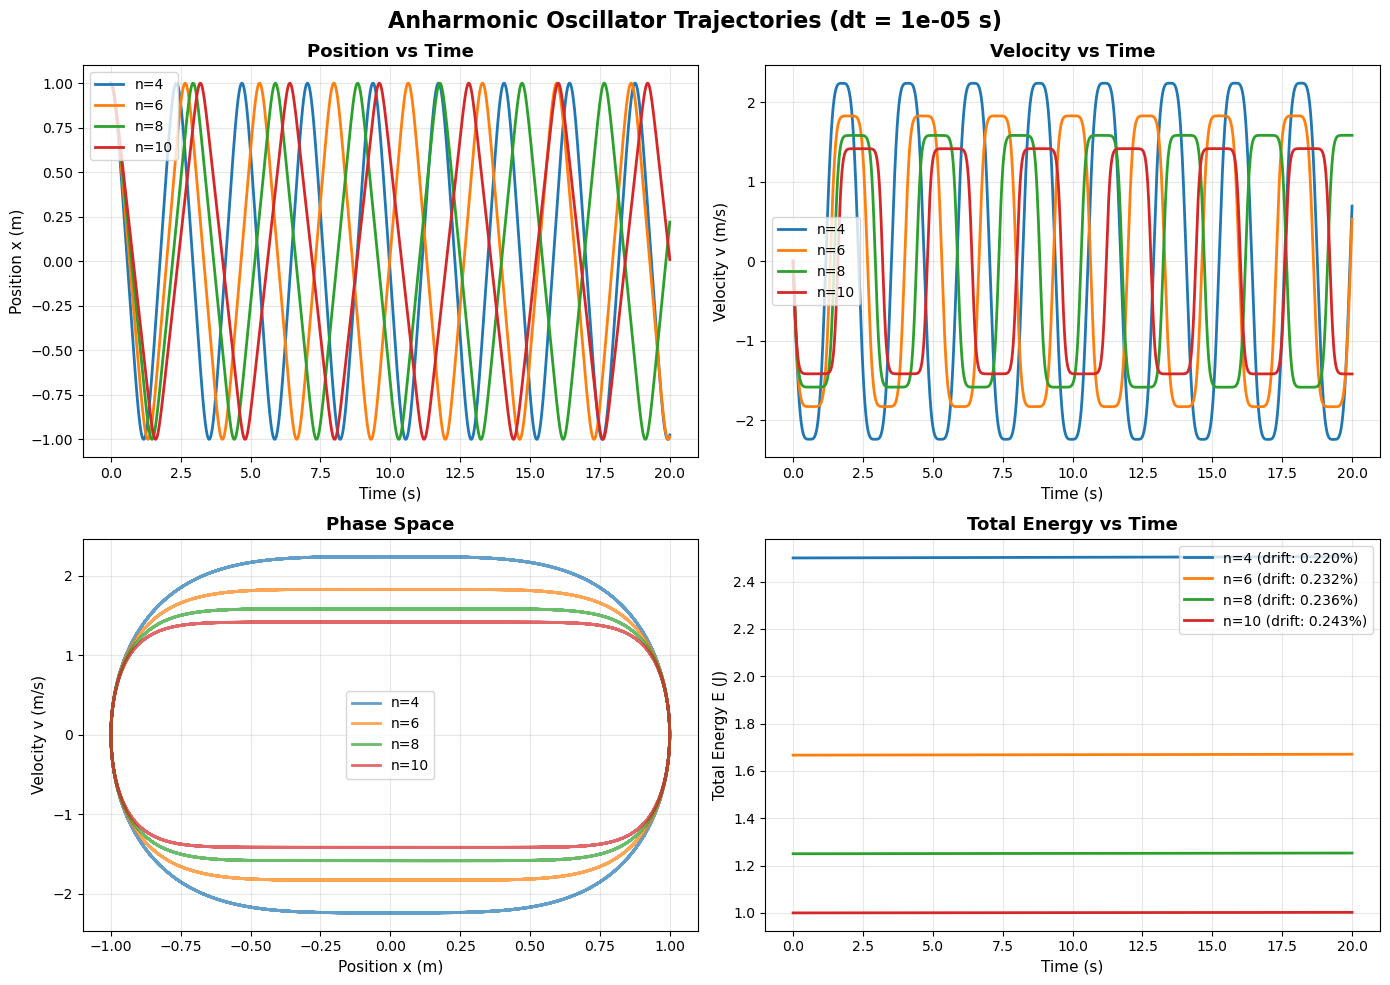

In [227]:
# Compare trajectories for different powers with fixed dt = 0.001
dt_compare = 0.00001

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Anharmonic Oscillator Trajectories (dt = {dt_compare} s)', fontsize=16, fontweight='bold')

# Position vs Time
axes[0, 0].set_title('Position vs Time', fontsize=13, fontweight='bold')
for n in n_values:
    data = results[n][dt_compare]
    axes[0, 0].plot(data['t'], data['x'], label=f'n={n}', linewidth=2)
axes[0, 0].set_xlabel('Time (s)', fontsize=11)
axes[0, 0].set_ylabel('Position x (m)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Velocity vs Time
axes[0, 1].set_title('Velocity vs Time', fontsize=13, fontweight='bold')
for n in n_values:
    data = results[n][dt_compare]
    axes[0, 1].plot(data['t'], data['v'], label=f'n={n}', linewidth=2)
axes[0, 1].set_xlabel('Time (s)', fontsize=11)
axes[0, 1].set_ylabel('Velocity v (m/s)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Phase Space (v vs x)
axes[1, 0].set_title('Phase Space', fontsize=13, fontweight='bold')
for n in n_values:
    data = results[n][dt_compare]
    axes[1, 0].plot(data['x'], data['v'], label=f'n={n}', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('Position x (m)', fontsize=11)
axes[1, 0].set_ylabel('Velocity v (m/s)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Energy vs Time
axes[1, 1].set_title('Total Energy vs Time', fontsize=13, fontweight='bold')
for n in n_values:
    data = results[n][dt_compare]
    percent_diff = data['percent_diff']
    axes[1, 1].plot(data['t'], data['E'], label=f'n={n} (drift: {percent_diff:.3f}%)', linewidth=2)
axes[1, 1].set_xlabel('Time (s)', fontsize=11)
axes[1, 1].set_ylabel('Total Energy E (J)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [223]:
# Create a comprehensive table of results
print("=" * 80)
print(" ANHARMONIC OSCILLATOR SIMULATION RESULTS")
print("=" * 80)
print(f"\nPhysical Parameters:")
print(f"  Mass m = {m} kg")
print(f"  Spring constant k = {k} N/m")
print(f"  Initial position x₀ = {x0} m")
print(f"  Initial velocity v₀ = {v0} m/s")
print(f"  Simulation time = {t_max_anh} s")
print("\n" + "=" * 80)

for n in n_values:
    print(f"\nPower n = {n}  [Potential: V(x) = (1/{n})kx^{n}]")
    print("-" * 80)
    print(f"{'Time Step dt':>15} {'# Steps':>10} {'Initial E (J)':>15} {'Final E (J)':>15} {'Drift (%)':>12}")
    print("-" * 80)
    
    for dt_anh in dt_values:
        data = results[n][dt_anh]
        N_steps = len(data['t'])
        E_init = data['E_initial']
        E_final = data['E_final']
        drift = data['percent_diff']
        
        print(f"{dt_anh:>15.5f} {N_steps:>10} {E_init:>15.6f} {E_final:>15.6f} {drift:>12.4f}")

print("\n" + "=" * 80)

 ANHARMONIC OSCILLATOR SIMULATION RESULTS

Physical Parameters:
  Mass m = 1.0 kg
  Spring constant k = 10.0 N/m
  Initial position x₀ = 1.0 m
  Initial velocity v₀ = 0.0 m/s
  Simulation time = 20.0 s


Power n = 4  [Potential: V(x) = (1/4)kx^4]
--------------------------------------------------------------------------------
   Time Step dt    # Steps   Initial E (J)     Final E (J)    Drift (%)
--------------------------------------------------------------------------------
        0.10000        200        2.500000             nan          nan
        0.01000       2000        2.500000             nan          nan
        0.00100      20000        2.500000        3.151653      26.0661
        0.00010     200000        2.500000        2.556025       2.2410
        0.00001    1999999        2.500000        2.505508       0.2203

Power n = 6  [Potential: V(x) = (1/6)kx^6]
--------------------------------------------------------------------------------
   Time Step dt    # Steps   Initi